In [167]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [168]:
df = pd.read_parquet("../data/cleaned.parquet")
df.head(5)

,crash date,crash time,borough,zip code,latitude,longitude,location,on street name,cross street name,off street name,...,contributing factor vehicle 5,collision_id,vehicle type code 1,vehicle type code 2,vehicle type code 3,vehicle type code 4,vehicle type code 5,month,hour_of_collision,time_period
0,2020-08-29,1900-01-01 15:40:00,bronx,10466.0,40.89210,-73.833760,point (-73.83376 40.8921),pratt avenue,strang avenue,NaN,...,NaN,4342908,sedan,station wagon/sport utility vehicle,NaN,NaN,NaN,august,15,afternoon
1,2020-08-29,1900-01-01 21:00:00,brooklyn,11221.0,40.69050,-73.919914,point (-73.919914 40.6905),bushwick avenue,palmetto street,NaN,...,NaN,4343555,sedan,sedan,NaN,NaN,NaN,august,21,evening
2,2020-08-29,1900-01-01 18:20:00,NaN,NaN,40.81650,-73.946556,point (-73.946556 40.8165),8 avenue,NaN,NaN,...,NaN,4343142,station wagon/sport utility vehicle,NaN,NaN,NaN,NaN,august,18,evening
3,2020-08-29,1900-01-01 00:00:00,bronx,10459.0,40.82472,-73.892960,point (-73.89296 40.82472),NaN,NaN,1047 simpson street,...,NaN,4343588,station wagon/sport utility vehicle,station wagon/sport utility vehicle,sedan,motorcycle,NaN,august,0,night
4,2020-08-29,1900-01-01 17:10:00,brooklyn,11203.0,40.64989,-73.933890,point (-73.93389 40.64989),NaN,NaN,4609 snyder avenue,...,NaN,4342953,sedan,sedan,NaN,NaN,NaN,august,17,afternoon


In [169]:
df["hour_of_collision"].unique()

array([15, 21, 18,  0, 17,  3, 19,  9, 14, 22,  4,  6, 13, 10, 12,  1,  8,
       23,  7, 16, 11,  2,  5, 20], dtype=int32)

In [170]:
df.head(5)

,crash date,crash time,borough,zip code,latitude,longitude,location,on street name,cross street name,off street name,...,contributing factor vehicle 5,collision_id,vehicle type code 1,vehicle type code 2,vehicle type code 3,vehicle type code 4,vehicle type code 5,month,hour_of_collision,time_period
0,2020-08-29,1900-01-01 15:40:00,bronx,10466.0,40.89210,-73.833760,point (-73.83376 40.8921),pratt avenue,strang avenue,NaN,...,NaN,4342908,sedan,station wagon/sport utility vehicle,NaN,NaN,NaN,august,15,afternoon
1,2020-08-29,1900-01-01 21:00:00,brooklyn,11221.0,40.69050,-73.919914,point (-73.919914 40.6905),bushwick avenue,palmetto street,NaN,...,NaN,4343555,sedan,sedan,NaN,NaN,NaN,august,21,evening
2,2020-08-29,1900-01-01 18:20:00,NaN,NaN,40.81650,-73.946556,point (-73.946556 40.8165),8 avenue,NaN,NaN,...,NaN,4343142,station wagon/sport utility vehicle,NaN,NaN,NaN,NaN,august,18,evening
3,2020-08-29,1900-01-01 00:00:00,bronx,10459.0,40.82472,-73.892960,point (-73.89296 40.82472),NaN,NaN,1047 simpson street,...,NaN,4343588,station wagon/sport utility vehicle,station wagon/sport utility vehicle,sedan,motorcycle,NaN,august,0,night
4,2020-08-29,1900-01-01 17:10:00,brooklyn,11203.0,40.64989,-73.933890,point (-73.93389 40.64989),NaN,NaN,4609 snyder avenue,...,NaN,4342953,sedan,sedan,NaN,NaN,NaN,august,17,afternoon


In [171]:
hourly = df.groupby("hour_of_collision").agg(
     hour_of_collision_count = ("hour_of_collision","size")
).reset_index()
hourly

,hour_of_collision,hour_of_collision_count
0,0,2948
1,1,1474
2,2,1139
3,3,989
4,4,975
5,5,1178
6,6,1868
7,7,2463
8,8,3678
9,9,3439


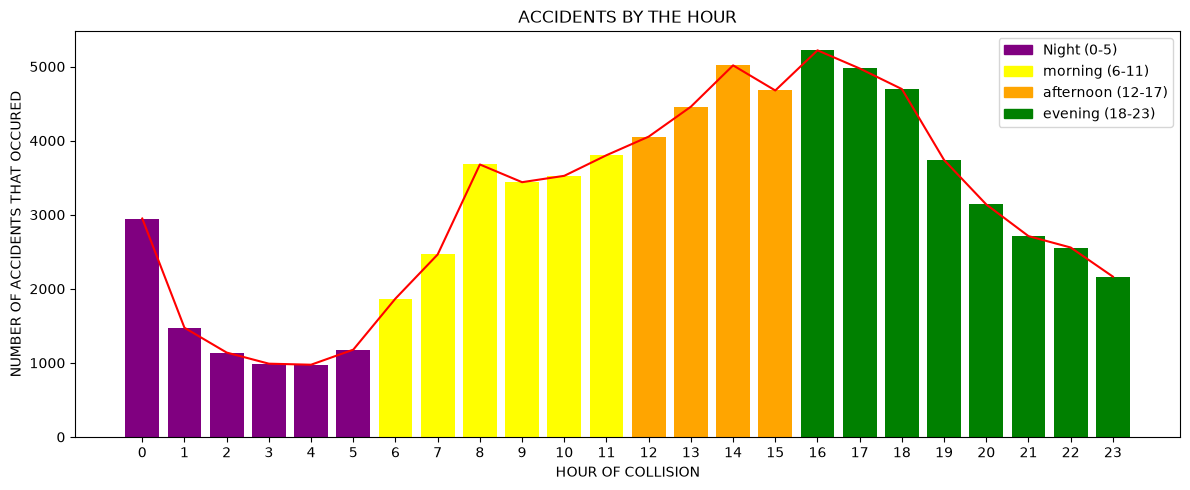

In [172]:
colors = []
for hour in hourly["hour_of_collision"]:
    if 0 <= hour <=5:
        colors.append("purple")
    elif 6 <= hour <= 11:
        colors.append("yellow")
    elif 12 <= hour <= 15 :
        colors.append("orange")
    else :
        colors.append("green")
            


legend = [Patch(color="purple",label="Night (0-5)"),
          Patch(color="yellow",label="morning (6-11)"),
          Patch(color="orange",label="afternoon (12-17)"),
          Patch(color="green",label="evening (18-23)")
          ]

plt.figure(figsize=(12,5))
plt.bar(hourly["hour_of_collision"],hourly["hour_of_collision_count"],color=colors)
plt.plot(hourly["hour_of_collision"],hourly["hour_of_collision_count"],color="red")
plt.legend(handles = legend)
plt.ticklabel_format(style="plain",axis="y")
plt.title("ACCIDENTS BY THE HOUR")
plt.xlabel("HOUR OF COLLISION")
plt.ylabel("NUMBER OF ACCIDENTS THAT OCCURED")
plt.xticks(hourly["hour_of_collision"])
plt.tight_layout()
plt.show()

In [173]:
period_accident_count = df.groupby("time_period").agg(
    period_count = ("time_period","size")
).reset_index()
period_accident_count

,time_period,period_count
0,afternoon,28398
1,evening,19004
2,morning,18776
3,night,8703


In [174]:
df["month"].unique()

<ArrowStringArray>
['august', 'july', 'june', 'may', 'april', 'march', 'february', 'january']
Length: 8, dtype: str

In [186]:
month_order = ['january','february','march','april','may','june','july','august']

In [189]:
monthly_accident_rate = df.groupby("month").agg(
    accident_count = ("month","size")
).reset_index()
monthly_accident_rate["month"] = pd.Categorical(monthly_accident_rate["month"],categories=month_order,ordered=True)
monthly_accident_rate = monthly_accident_rate.sort_values("month")
monthly_accident_rate

,month,accident_count
3,january,14287
2,february,13684
6,march,11057
0,april,4116
7,may,6149
5,june,7616
4,july,9225
1,august,8747


In [177]:
monthly_accident_rate["accident_count"].sum()

np.int64(74881)

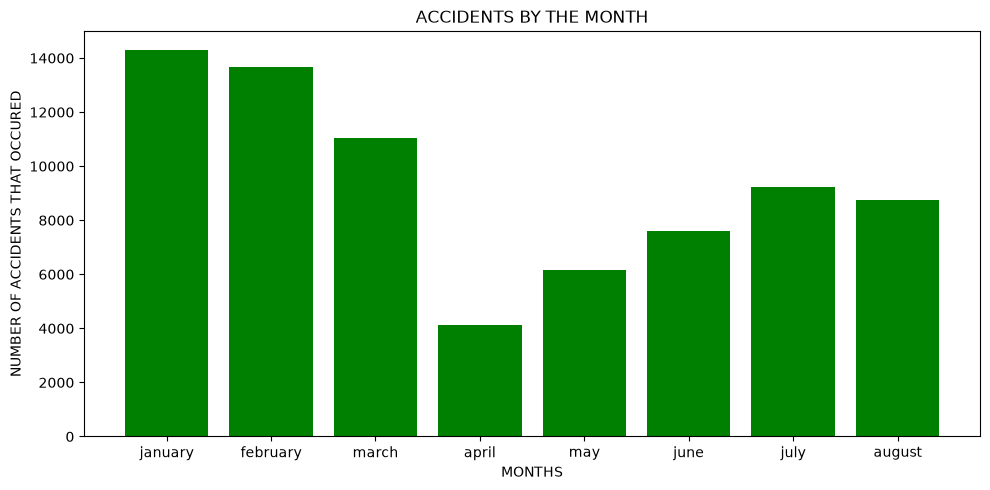

In [201]:
plt.figure(figsize=(10,5))
plt.bar(monthly_accident_rate["month"],monthly_accident_rate["accident_count"],color="green")
plt.ticklabel_format(style="plain",axis="y")
plt.title("ACCIDENTS BY THE MONTH")
plt.xlabel("MONTHS")
plt.ylabel("NUMBER OF ACCIDENTS THAT OCCURED")
plt.xticks(monthly_accident_rate["month"])

plt.tight_layout()
plt.show()

In [197]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   crash date                     74881 non-null  datetime64[us]
 1   crash time                     74881 non-null  datetime64[us]
 2   borough                        49140 non-null  str           
 3   zip code                       49134 non-null  float64       
 4   latitude                       68935 non-null  float64       
 5   longitude                      68935 non-null  float64       
 6   location                       68935 non-null  str           
 7   on street name                 55444 non-null  str           
 8   cross street name              35681 non-null  str           
 9   off street name                19437 non-null  str           
 10  number of persons injured      74881 non-null  int64         
 11  number of persons killed  